In [9]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


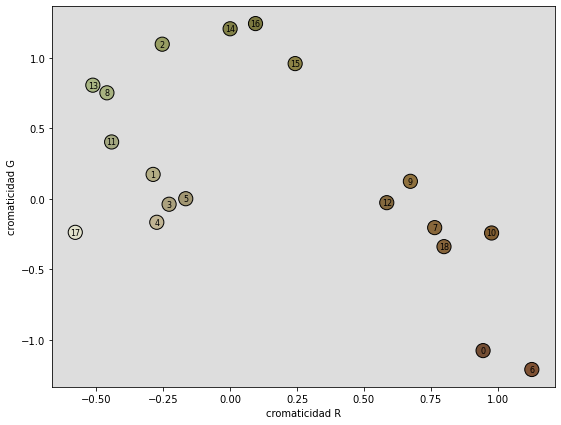

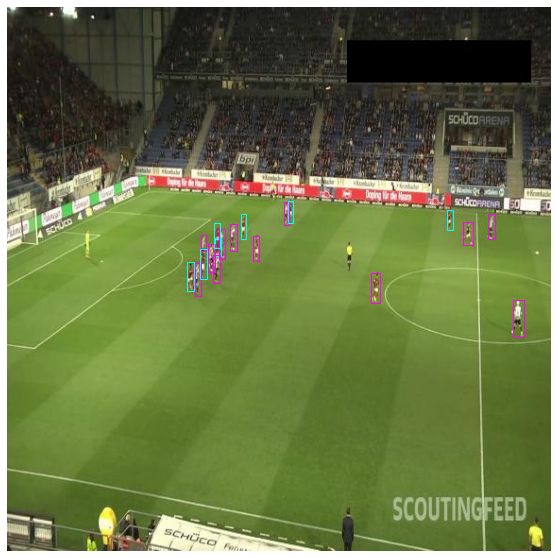

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from src.equipos import colorRecorte, descriptor, clasificarEquipos
from src.viz import recortesTorso, dibujarCajas
from src.pipeline import analizarImagen
from src.CocoDataset import CocoDataset 

IMG_ID = 41

ds = CocoDataset("../data/raw/football-players/valid")
img = ds.imagen(IMG_ID)

cajas = [c for c, k in ds.cajas(IMG_ID) if k == "player"]


recortes = recortesTorso(ds, IMG_ID, cajas)
colores  = np.array([colorRecorte(r) for r in recortes])
X = descriptor(colores)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X[:, 0], X[:, 1], c=colores / 255, s=200, edgecolors="black", linewidths=1)

for i, (a, b) in enumerate(X[:, :2]):
    ax.annotate(str(i), (a, b), fontsize=8, ha="center", va="center")

ax.set_xlabel("cromaticidad R")
ax.set_ylabel("cromaticidad G")
ax.set_facecolor("#dddddd")

pares = analizarImagen(ds, IMG_ID, cajas)
fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(ds.imagen(IMG_ID))
ax.axis("off")
dibujarCajas(ax, pares, colores={"e0": "cyan", "e1": "magenta"})
plt.show()

In [11]:
et3 = clasificarEquipos(X, k=2)              # como ahora, 3 dims
et1 = clasificarEquipos(X[:, :1], k=2)       # solo cromaticidad R
print(np.bincount(et3), np.bincount(et1))
print(np.round(colores).astype(int))

[ 7 12] [ 7 12]
[[116  78  52]
 [178 173 132]
 [152 158  99]
 [171 160 126]
 [192 180 147]
 [162 150 115]
 [127  82  52]
 [136 103  59]
 [168 178 128]
 [142 113  62]
 [128  93  49]
 [163 167 128]
 [132 105  62]
 [168 180 130]
 [130 129  72]
 [140 130  70]
 [123 120  64]
 [224 224 202]
 [132  98  58]]


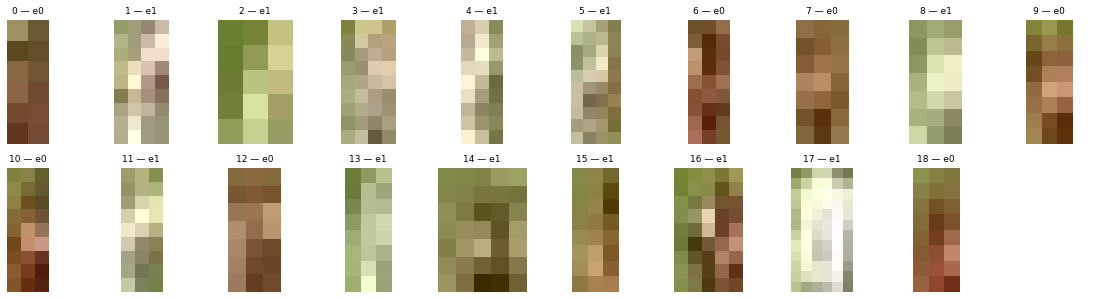

In [12]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i, (r, e) in enumerate(zip(recortes, et3)):
    axes.flat[i].imshow(r)
    axes.flat[i].set_title(f"{i} — e{e}", fontsize=9)
    axes.flat[i].axis("off")
for j in range(len(recortes), 20):
    axes.flat[j].axis("off")